**Exercícios Rotulação de Componentes Conexos**
exercícios obtidos em http://homepages.inf.ed.ac.uk/rbf/HIPR2/label.htm


1. Implemente o algoritmo de rotulação de componentes conexos (algoritmo do slide ou por outra solução) e aplique sobre a imagem binária art8.png. Indique qual vizinhança será considerada (4 ou 8)
Mostre os resultados na forma da imagem art8lab1.png e art8lab2.png

art8.png:
![art8.png](attachment:image.png)
art8lab1.png:
![image.png](attachment:image-2.png)
art8lab2.png:
![image.png](attachment:image-3.png)


In [4]:
from google.colab import files
import io

uploaded = files.upload()
IMAGE_PATH = list(uploaded.keys())[0]


Saving download.png to download.png
Arquivo carregado: download.png


In [5]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib


In [6]:
class UnionFind:
    def __init__(self, n: int):
        self.parent = np.arange(n, dtype=np.int32)

    def find_root(self, x: int) -> int:
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x

    def union(self, a: int, b: int):
        ra, rb = self.find_root(a), self.find_root(b)
        if ra != rb:
            if ra < rb:
                self.parent[rb] = ra
            else:
                self.parent[ra] = rb

    def flatten(self):
        for i in range(len(self.parent)):
            self.parent[i] = self.find_root(i)


In [16]:
def first_pass(binary: np.ndarray):
    H, W = binary.shape
    labels = np.zeros((H, W), dtype=np.int32)
    next_label = 1
    uf = UnionFind(H * W + 1)

    for r in range(H):
        for c in range(W):
            if not binary[r, c]:
                continue

            neighbor_labels = []
            if r > 0:
                if c > 0   and labels[r-1, c-1]: neighbor_labels.append(labels[r-1, c-1])
                if              labels[r-1, c  ]: neighbor_labels.append(labels[r-1, c  ])
                if c < W-1 and labels[r-1, c+1]: neighbor_labels.append(labels[r-1, c+1])
            if c > 0       and labels[r  , c-1]: neighbor_labels.append(labels[r  , c-1])

            if not neighbor_labels:
                labels[r, c] = next_label
                next_label += 1
            else:
                min_label = min(neighbor_labels)
                labels[r, c] = min_label
                for nl in neighbor_labels:
                    uf.union(min_label, nl)

    return labels, uf


def second_pass(labels: np.ndarray, uf: UnionFind) -> np.ndarray:
    uf.flatten()

    resolved = uf.parent[labels.ravel()].reshape(labels.shape)

    unique_roots = np.unique(resolved[resolved > 0])
    remap = np.zeros(unique_roots.max() + 1, dtype=np.int32)
    remap[unique_roots] = np.arange(1, len(unique_roots) + 1)

    return np.where(resolved > 0, remap[resolved], 0)


In [8]:
def label_components(image_path: str):
    img  = Image.open(image_path).convert("L")
    gray = np.array(img, dtype=np.uint8)

    threshold = int(gray[gray > 0].mean()) if gray.max() > 0 else 128
    binary = (gray >= threshold).astype(np.uint8)

    # Two-Pass
    labels_tmp, uf = first_pass(binary)
    labels_final   = second_pass(labels_tmp, uf)

    n_components = int(labels_final.max())
    return binary, labels_final, n_components


In [9]:
def compute_stats(labels: np.ndarray, n: int) -> list:
    label_ids = np.arange(1, n + 1)

    masks = labels[np.newaxis, :, :] == label_ids[:, np.newaxis, np.newaxis]
    areas = masks.sum(axis=(1, 2))

    rows_idx = np.where(masks, np.arange(labels.shape[0])[np.newaxis, :, np.newaxis], -1)
    cols_idx = np.where(masks, np.arange(labels.shape[1])[np.newaxis, np.newaxis, :], -1)

    stats = []
    for i in range(n):
        r_vals = rows_idx[i][masks[i]]
        c_vals = cols_idx[i][masks[i]]
        stats.append({
            "label":    i + 1,
            "area":     int(areas[i]),
            "bbox":     (int(r_vals.min()), int(c_vals.min()),
                         int(r_vals.max()), int(c_vals.max())),
            "centroid": (float(r_vals.mean()), float(c_vals.mean())),
        })
    return stats


In [10]:
def visualize(binary: np.ndarray, labels: np.ndarray, stats: list):
    n    = len(stats)
    cmap = matplotlib.colormaps.get_cmap("tab10").resampled(n + 1)

    colored = cmap(labels / max(labels.max(), 1))
    colored[labels == 0] = [0, 0, 0, 1]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Rotulação de Componentes Conexos  |  Vizinhança-8",
                 fontsize=14, fontweight="bold")

    axes[0].imshow(binary, cmap="gray")
    axes[0].set_title("Imagem Binária (entrada)")
    axes[0].axis("off")

    axes[1].imshow(colored)
    axes[1].set_title(f"Componentes rotuladas  (N = {n})")
    axes[1].axis("off")

    axes[2].imshow(colored)
    for s in stats:
        r0, c0, r1, c1 = s["bbox"]
        rect = plt.Rectangle((c0 - 2, r0 - 2), (c1 - c0) + 4, (r1 - r0) + 4,
                              linewidth=1.5, edgecolor="yellow", facecolor="none")
        axes[2].add_patch(rect)
        axes[2].text(s["centroid"][1], s["centroid"][0], str(s["label"]),
                     color="white", fontsize=9, ha="center", va="center",
                     fontweight="bold",
                     bbox=dict(boxstyle="round,pad=0.1", fc="black", alpha=0.5))
    axes[2].set_title("Bounding boxes + rótulos")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()


  Rotulação de Componentes Conexos — Vizinhança 8

• Dimensões da imagem : (166, 166)
• Vizinhança utilizada: 8-conectividade
• Componentes conexos : 8

 Rótulo   Área (px)         Centróide (r,c)  Bounding Box (r0,c0,r1,c1)
---------------------------------------------------------------------------
     1         334   (  33.4,   34.2)   (18,20,48,49)
     2         335   (  39.9,   88.8)   (28,77,52,101)
     3         336   (  69.9,  121.5)   (55,106,85,137)
     4         338   (  77.1,   61.6)   (63,47,92,76)
     5         327   ( 104.7,   94.9)   (89,80,120,110)
     6         303   ( 100.5,   30.2)   (90,19,113,43)
     7         334   ( 136.4,  134.6)   (121,119,152,150)
     8         312   ( 135.0,   73.7)   (123,59,148,88)


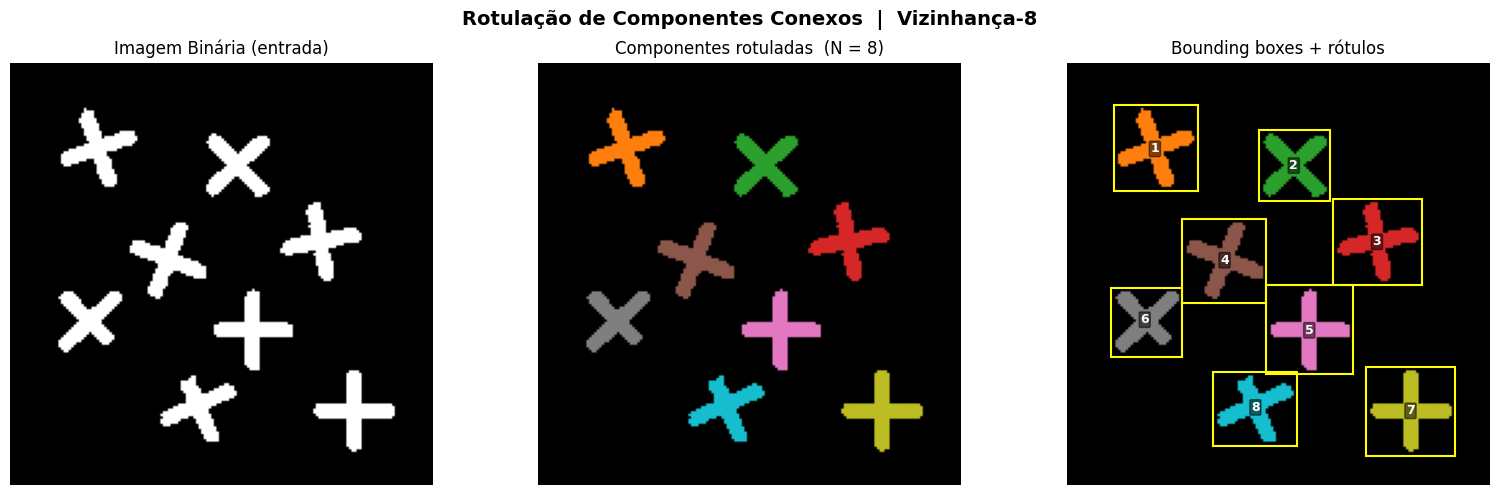

In [11]:
print("=" * 55)
print("  Rotulação de Componentes Conexos — Vizinhança 8")
print("=" * 55)

binary, labels, n_comp = label_components(IMAGE_PATH)

print(f"\n• Dimensões da imagem : {binary.shape}")
print(f"• Vizinhança utilizada: 8-conectividade")
print(f"• Componentes conexos : {n_comp}\n")


2. Calcule o número de objetos da imagem clc3.png. Note que antes será necessário binarizar a imagem. Para isso, considere um limiar (*threshold*) de 67, isto é, valores acima de 167 na imagem original recebem zero, e os abaixo recebem 1 (o que resulta na imagem clc3thr1.png).

clc3.png
![clc3.png](https://github.com/btravencolo/gbc216-labs-2026-01/blob/main/Lab02%20-%20Connected%20Components/clc3.png?raw=1)
clc3thr1
![clc3thr1.png](https://github.com/btravencolo/gbc216-labs-2026-01/blob/main/Lab02%20-%20Connected%20Components/clc3thr1.png?raw=1)
clc3lab1
![clc3lab1.png](https://github.com/btravencolo/gbc216-labs-2026-01/blob/main/Lab02%20-%20Connected%20Components/clc3lab1.png?raw=1)


In [1]:
from google.colab import files

uploaded = files.upload()
IMAGE_PATH = list(uploaded.keys())[0]


Saving clc3.png to clc3.png


In [2]:
import numpy as np
from PIL import Image
import matplotlib
import matplotlib.pyplot as plt


Dimensões        : (260, 200)
Threshold usado  : 167
Pixels foreground: 2189
Pixels de fundo  : 49811


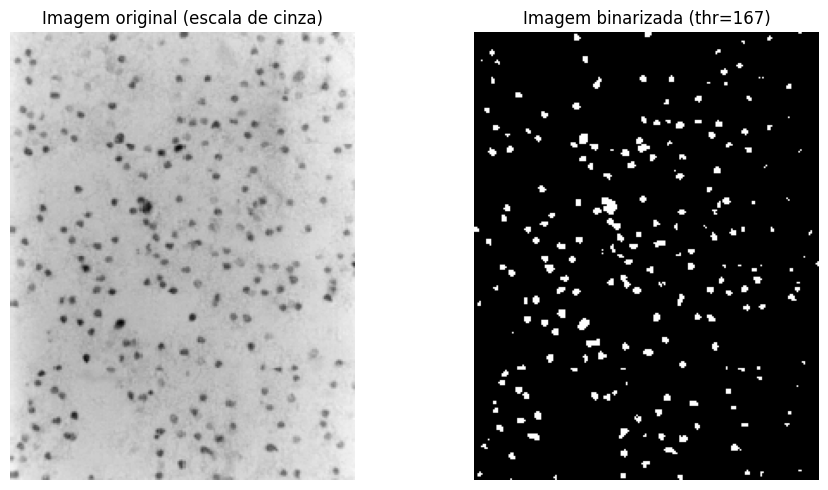

In [3]:
THRESHOLD = 167

img  = Image.open(IMAGE_PATH).convert("L")
gray = np.array(img, dtype=np.uint8)

binary = (gray < THRESHOLD).astype(np.uint8)

print(f"Dimensões        : {gray.shape}")
print(f"Threshold usado  : {THRESHOLD}")
print(f"Pixels foreground: {binary.sum()}")
print(f"Pixels de fundo  : {(binary == 0).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray,   cmap="gray"); axes[0].set_title("Imagem original (escala de cinza)"); axes[0].axis("off")
axes[1].imshow(binary, cmap="gray"); axes[1].set_title(f"Imagem binarizada (thr={THRESHOLD})");   axes[1].axis("off")
plt.tight_layout(); plt.show()


In [4]:
class UnionFind:
    def __init__(self, n: int):
        self.parent = np.arange(n, dtype=np.int32)

    def find_root(self, x: int) -> int:
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x

    def union(self, a: int, b: int):
        ra, rb = self.find_root(a), self.find_root(b)
        if ra != rb:
            if ra < rb: self.parent[rb] = ra
            else:       self.parent[ra] = rb

    def flatten(self):
        for i in range(len(self.parent)):
            self.parent[i] = self.find_root(i)


In [5]:
def first_pass(binary: np.ndarray):
    H, W = binary.shape
    labels     = np.zeros((H, W), dtype=np.int32)
    next_label = 1
    uf         = UnionFind(H * W + 1)

    for r in range(H):
        for c in range(W):
            if not binary[r, c]:
                continue

            nb_labels = []
            if r > 0:
                if c > 0   and labels[r-1, c-1]: nb_labels.append(labels[r-1, c-1])
                if              labels[r-1, c  ]: nb_labels.append(labels[r-1, c  ])
                if c < W-1 and labels[r-1, c+1]: nb_labels.append(labels[r-1, c+1])
            if c > 0       and labels[r  , c-1]: nb_labels.append(labels[r  , c-1])

            if not nb_labels:
                labels[r, c] = next_label
                next_label  += 1
            else:
                ml = min(nb_labels)
                labels[r, c] = ml
                for nl in nb_labels:
                    uf.union(ml, nl)

    return labels, uf


def second_pass(labels: np.ndarray, uf: UnionFind) -> np.ndarray:
    uf.flatten()

    resolved = uf.parent[labels.ravel()].reshape(labels.shape)

    unique_roots = np.unique(resolved[resolved > 0])
    remap        = np.zeros(unique_roots.max() + 1, dtype=np.int32)
    remap[unique_roots] = np.arange(1, len(unique_roots) + 1)

    return np.where(resolved > 0, remap[resolved], 0)


In [6]:
labels_tmp, uf = first_pass(binary)
labels         = second_pass(labels_tmp, uf)
n_objetos      = int(labels.max())

print("=" * 45)
print(f"  Número de objetos encontrados: {n_objetos}")
print("=" * 45)


  Número de objetos encontrados: 212


In [7]:
def compute_stats(labels: np.ndarray, n: int) -> list:
    label_ids = np.arange(1, n + 1)

    masks = labels[np.newaxis, :, :] == label_ids[:, np.newaxis, np.newaxis]
    areas = masks.sum(axis=(1, 2))

    rows_idx = np.where(masks, np.arange(labels.shape[0])[np.newaxis, :, np.newaxis], -1)
    cols_idx = np.where(masks, np.arange(labels.shape[1])[np.newaxis, np.newaxis, :], -1)

    stats = []
    for i in range(n):
        r_vals = rows_idx[i][masks[i]]
        c_vals = cols_idx[i][masks[i]]
        stats.append({
            "label":    i + 1,
            "area":     int(areas[i]),
            "centroid": (float(r_vals.mean()), float(c_vals.mean())),
            "bbox":     (int(r_vals.min()), int(c_vals.min()),
                         int(r_vals.max()), int(c_vals.max())),
        })
    return stats

stats = compute_stats(labels, n_objetos)

areas = np.array([s["area"] for s in stats])
print(f"Total de objetos : {n_objetos}")


Total de objetos : 212
Área média       : 10.3 px
Área mínima      : 1 px  (objeto 9)
Área máxima      : 62 px  (objeto 68)
Desvio padrão    : 6.9 px


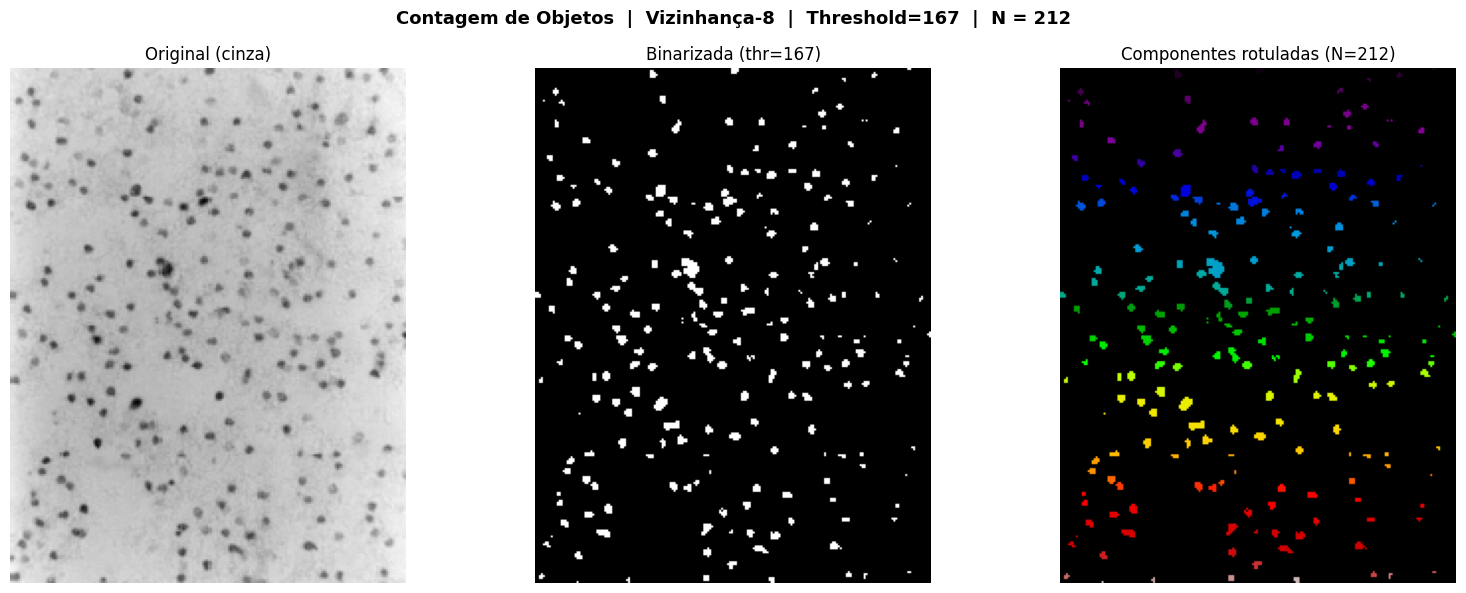

In [8]:
cmap    = matplotlib.colormaps.get_cmap("nipy_spectral").resampled(n_objetos + 1)
colored = cmap(labels / max(labels.max(), 1))
colored[labels == 0] = [0, 0, 0, 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle(f"Contagem de Objetos  |  Vizinhança-8  |  Threshold={THRESHOLD}  |  N = {n_objetos}",
             fontsize=13, fontweight="bold")

axes[0].imshow(gray,   cmap="gray")
axes[0].set_title("Original (cinza)"); axes[0].axis("off")

axes[1].imshow(binary, cmap="gray")
axes[1].set_title(f"Binarizada (thr={THRESHOLD})"); axes[1].axis("off")

plt.tight_layout()
plt.show()


3. Calcule a distância média entre os objetos da imagem anterior. Mostre um histograma com as distâncias e o valor médio.

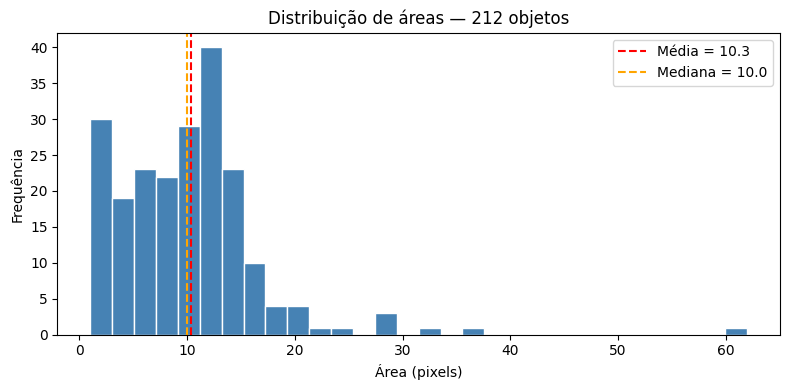

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(areas, bins=30, color="steelblue", edgecolor="white")
ax.set_xlabel("Área (pixels)")
ax.set_ylabel("Frequência")
ax.set_title(f"Distribuição de áreas — {n_objetos} objetos")
ax.axvline(areas.mean(), color="red",    linestyle="--", label=f"Média = {areas.mean():.1f}")
ax.axvline(np.median(areas), color="orange", linestyle="--", label=f"Mediana = {np.median(areas):.1f}")
ax.legend()
plt.tight_layout()
plt.show()


In [13]:
# code here

4. Mostra a Transformada Distância da imagem do exercício 1

In [10]:
from google.colab import files
uploaded = files.upload()
IMAGE_PATH = list(uploaded.keys())[0]


Saving download.png to download.png
Arquivo carregado: download.png


In [11]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt, distance_transform_cdt


Dimensões  : (166, 166)
Threshold  : 22
Foreground : 2619 px


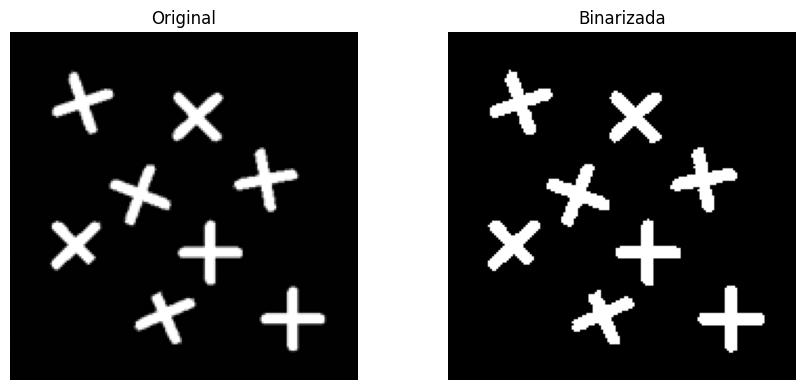

In [12]:
img  = Image.open(IMAGE_PATH).convert("L")
gray = np.array(img, dtype=np.uint8)

threshold = int(gray[gray > 0].mean())
binary    = (gray >= threshold).astype(np.uint8)

print(f"Dimensões  : {gray.shape}")
print(f"Threshold  : {threshold}")
print(f"Foreground : {binary.sum()} px")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(gray,   cmap="gray"); axes[0].set_title("Original");   axes[0].axis("off")
axes[1].imshow(binary, cmap="gray"); axes[1].set_title("Binarizada"); axes[1].axis("off")
plt.tight_layout(); plt.show()


In [13]:
dt_euclidean  = distance_transform_edt(binary)
dt_cityblock  = distance_transform_cdt(binary, metric='taxicab')
dt_chessboard = distance_transform_cdt(binary, metric='chessboard')

print(f"Distância máxima — Euclidiana : {dt_euclidean.max():.2f} px")
print(f"Distância máxima — City-Block : {dt_cityblock.max():.0f} px")
print(f"Distância máxima — Chessboard : {dt_chessboard.max():.0f} px")


Distância máxima — Euclidiana : 5.10 px
Distância máxima — City-Block : 6 px
Distância máxima — Chessboard : 5 px


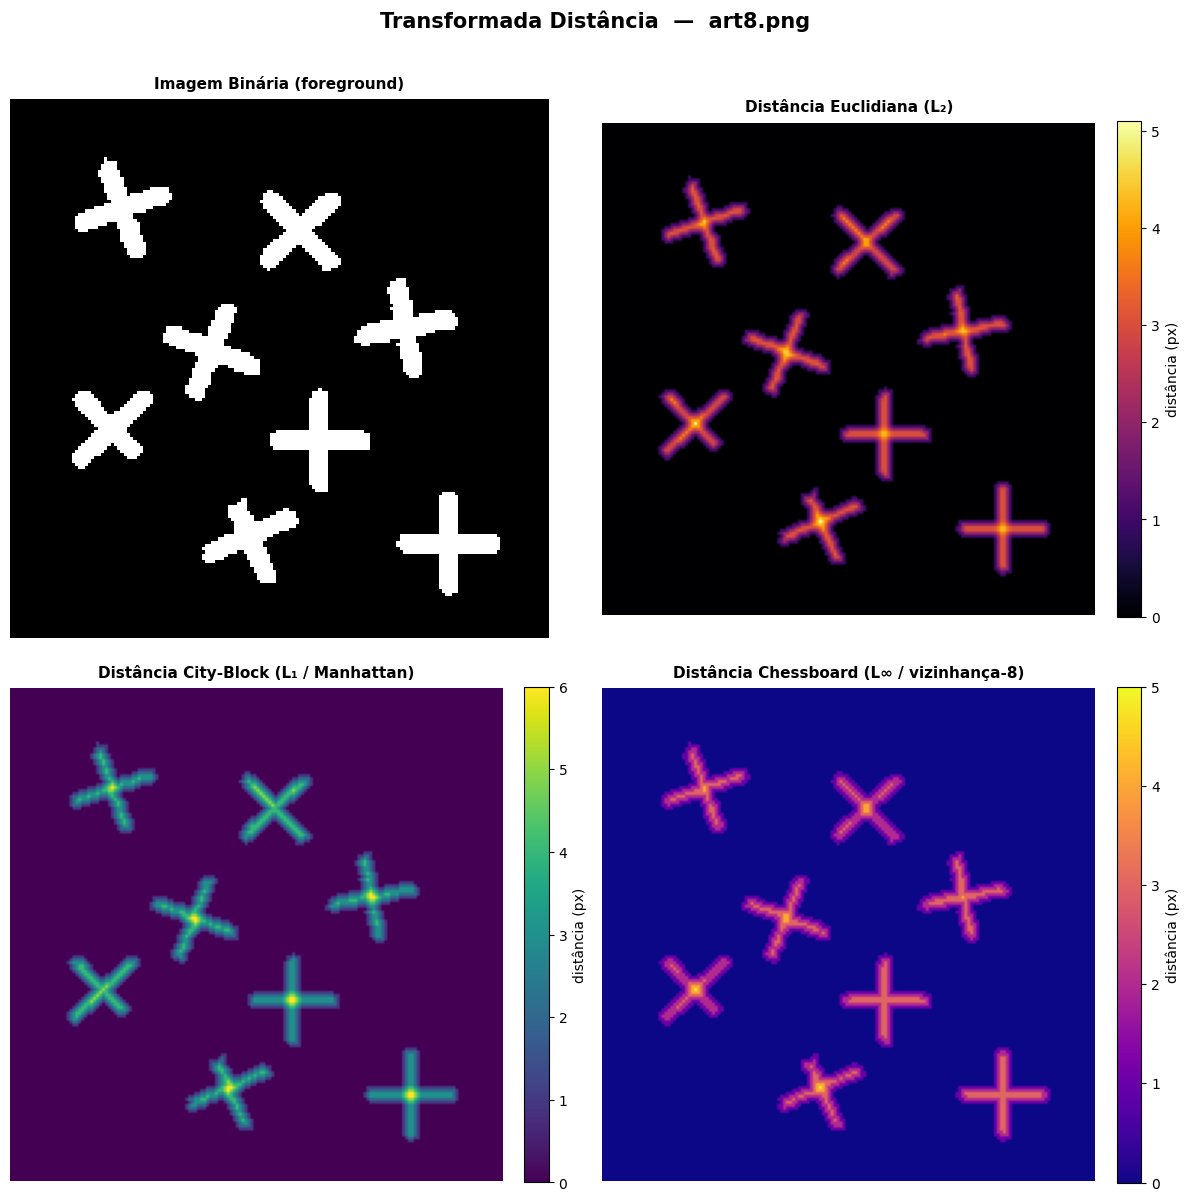

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle("Transformada Distância  —  art8.png", fontsize=15, fontweight="bold", y=1.01)

panels = [
    ("Imagem Binária (foreground)",            binary,        "gray",    False),
    ("Distância Euclidiana (L₂)",              dt_euclidean,  "inferno", True),
    ("Distância City-Block (L₁ / Manhattan)",  dt_cityblock,  "viridis", True),
    ("Distância Chessboard (L∞ / vizinhança-8)", dt_chessboard, "plasma", True),
]

for ax, (title, data, cmap, show_cbar) in zip(axes.ravel(), panels):
    im = ax.imshow(data, cmap=cmap)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
    ax.axis("off")
    if show_cbar:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="distância (px)")

plt.tight_layout()
plt.show()
